# Code for Normalizing Flows based on the Tabak-Turner paper

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import erf, gamma
from matplotlib.colors import LogNorm

def estimate_forward_KL(X, flow, log_rho_exact):

    # compute log-density under the exact model
    log_ex = log_rho_exact(X)

    # compute log-density under the flow estimate
    log_est = flow.log_prob(X)

    # Monte Carlo KL
    kl_mc = np.mean(log_ex - log_est)
    return kl_mc


class NormalizingFlow:
    """
    An implementation of the non-parametric density estimator using normalizing flows,
    as described in "A family of non-parametric density estimation algorithms"
    by E. G. Tabak and C. V. Turner.

    This implementation uses the method of composing simple, localized
    radial expansion maps. The parameters of each map are found by maximizing a
    local quadratic approximation to the log-likelihood.
    """

    def __init__(self, n_p=50, epsilon=0.5):
        """
        Initializes the density estimator.

        Args:
            n_p (int): The typical number of points each local map should influence.
                       This controls the resolution or "bandwidth" of the estimate.
                       Corresponds to n_p in equation (13) of the paper.
            epsilon (float): The maximum step size for the parameter of each map.
                             This caps the learning rate to ensure stability.
        """
        self.n_p = n_p
        self.epsilon = epsilon
        self.maps = []
        self.preconditioning = {}
        self.kl_history = []

    def _volume_n_ball(self, n):
        """Calculates the volume of an n-dimensional unit ball."""
        return np.pi**(n/2) / gamma(n/2 + 1)

    def _calculate_alpha(self, x0, n, m):
        """
        Calculates the length-scale 'alpha' for a map centered at x0, 
        based on equation (13) from the paper. The goal is to have the
        map's influence cover roughly n_p points.
        """
        omega_n = self._volume_n_ball(n)
        term = (omega_n**-1 * self.n_p / m)**(1/n)
        alpha = (2 * np.pi)**0.5 * term * np.exp(np.linalg.norm(x0)**2 / (2*n))
        return alpha

    def _radial_f(self, r, alpha):
        """
        The radial localization function f(r), based on equation (24).
        Handles the r=0 case to avoid division by zero.
        """
        f_vals = np.zeros_like(r)
        nonzero_r = r != 0
        zero_r = ~nonzero_r

        r_scaled = r[nonzero_r] / alpha
        f_vals[nonzero_r] = erf(r_scaled) / r[nonzero_r]
        f_vals[zero_r] = 2.0 / (alpha * np.sqrt(np.pi))
        return f_vals

    def _radial_f_prime(self, r, alpha):
        """
        The derivative of the radial localization function, f'(r).
        Handles the r=0 case, where the derivative is 0.
        """
        f_prime_vals = np.zeros_like(r)
        nonzero_r = r != 0
        
        r_nz = r[nonzero_r]
        r_scaled = r_nz / alpha
        
        term1 = (2.0 / (alpha * np.sqrt(np.pi))) * np.exp(-r_scaled**2)
        term2 = erf(r_scaled) / r_nz
        f_prime_vals[nonzero_r] = (term1 - term2) / r_nz
        
        return f_prime_vals

    def _min_sign_slogdet_subset(self, z0_subset, maps_with_candidate):
        """
        For the modified map y(z0) = z0 + sum_k beta_k f(r_k)(z0-x0_k),
        build J(z0) on a subset and return min(sign), min(logabsdet).
        """
        msub, n = z0_subset.shape
        J = np.tile(np.eye(n), (msub, 1, 1))

        I = np.eye(n)[None, :, :]

        for p in maps_with_candidate:
            x0, alpha, beta = p['x0'], p['alpha'], p['beta']
            diff = z0_subset - x0
            r = np.linalg.norm(diff, axis=1)

            f = self._radial_f(r, alpha)
            fp = self._radial_f_prime(r, alpha)

            outer = diff[:, :, None] * diff[:, None, :]  # msub x n x n

            coef = np.zeros_like(r)
            nz = (r > 0)
            coef[nz] = fp[nz] / r[nz]

            J += beta * (f[:, None, None] * I + coef[:, None, None] * outer)

        sign, logabsdet = np.linalg.slogdet(J)
        return np.min(sign), np.min(logabsdet)

    def fit(self, x, log_rho_exact=None, n_steps=1000):
        """
        Fits the density model to the data by building a sequence of maps.
        """
        m, n = x.shape
        tol = 1e-9  # Tolerance for Hessian

        # Starting map (preconditioning)
        mean = np.mean(x, axis=0)
        z = x - mean
        std = np.sqrt(np.mean(np.sum(z**2, axis=1)) / n)
        z /= std
        z_init = z.copy()

        self.preconditioning = {'mean': mean, 'std': std}
        self.maps = []
        self.kl_history = []

        # Iterative map building
        for i in range(n_steps):
            # 1. Select a center x0
            if np.random.rand() > 0.5:
                idx = np.random.randint(m)
                x0 = z[idx]                 # center sampled from transported particles
            else:
                x0 = np.random.randn(n)     # anchor to keep centers from drifting

            # 2. Calculate length-scale alpha
            alpha = self._calculate_alpha(x0, n, m)

            # 3. Calculate Gradient (G) and Hessian (H) of log-likelihood
            diff0 = z_init - x0
            r = np.linalg.norm(diff0, axis=1)
            f = self._radial_f(r, alpha)
            f_prime = self._radial_f_prime(r, alpha)

            term_G = n + np.dot(z, x0) - np.sum(z**2, axis=1)
            G = np.sum(term_G * f + r * f_prime)

            term_H1 = (n + r**2) * f**2
            term_H2 = 2 * r * f * f_prime
            term_H3 = (r * f_prime)**2
            H = -np.sum(term_H1 + term_H2 + term_H3)

            if np.abs(H) < tol:
                continue

            # 4. Calculate optimal step beta and constrain it
            beta = -G / H
            beta = np.clip(beta, -self.epsilon, self.epsilon)

            # ---- NEW: backtracking to enforce local invertibility (sign(det J)>0) ----
            beta_try = beta

            # check on a small subset for speed
            chk_sz = min(200, m)
            idx_chk = np.random.choice(m, size=chk_sz, replace=False)
            z0_chk = z_init[idx_chk]

            # shrink beta until Jacobian sign is positive everywhere on subset
            for _ in range(20):
                min_sign, _ = self._min_sign_slogdet_subset(
                    z0_chk,
                    self.maps + [{'x0': x0, 'alpha': alpha, 'beta': beta_try}]
                )
                if min_sign > 0:
                    break
                beta_try *= 0.5

            beta = beta_try
            if np.abs(beta) < 1e-12:
                # couldn't make it invertible; skip this step
                continue
            # ------------------------------------------------------------------------

            # 5. Apply the map to transform the data (your modified update)
            z = z + beta * f[:, np.newaxis] * diff0

            # 6. Store the map's parameters
            self.maps.append({'x0': x0, 'alpha': alpha, 'beta': beta})

            if log_rho_exact is not None:
                kl = estimate_forward_KL(x, self, log_rho_exact)
                self.kl_history.append(kl)

            if (i+1) % max(1, (n_steps//10)) == 0:
                if log_rho_exact is None:
                    print(f"Step {i+1}/{n_steps} completed")
                else:
                    print(f"Step {i+1}/{n_steps} completed, KL estimate: {self.kl_history[-1]:.4f}")

    def _transform(self, x_new):
        if x_new.ndim == 1:
            x_new = x_new.reshape(1, -1)
        m, n = x_new.shape

        # Preconditioning
        z0 = (x_new - self.preconditioning['mean']) / self.preconditioning['std']

        # Build y(z0) and Jacobian J(z0)
        y = z0.copy()
        J = np.tile(np.eye(n), (m, 1, 1))
        I = np.eye(n)[None, :, :]

        for p in self.maps:
            x0, alpha, beta = p['x0'], p['alpha'], p['beta']

            diff = z0 - x0
            r = np.linalg.norm(diff, axis=1)

            f = self._radial_f(r, alpha)
            fp = self._radial_f_prime(r, alpha)

            # Update y
            y += beta * f[:, None] * diff

            # Update Jacobian: I + sum beta*( f I + (fp/r) diff diff^T )
            outer = diff[:, :, None] * diff[:, None, :]

            coef = np.zeros_like(r)
            nz = (r > 0)
            coef[nz] = fp[nz] / r[nz]

            J += beta * (f[:, None, None] * I + coef[:, None, None] * outer)

        # Use slogdet for stability, and don't crash training on sign<=0
        sign, logabsdet = np.linalg.slogdet(J)

        log_J = -n * np.log(self.preconditioning['std']) + logabsdet
        bad = (sign <= 0)
        log_J[bad] = -np.inf

        return y, log_J

    def log_prob(self, x_new):
        if x_new.ndim == 1:
            x_new = x_new.reshape(1, -1)
        m, n = x_new.shape

        y, log_J = self._transform(x_new)
        log_prob_gaussian = -0.5 * np.sum(y**2, axis=1) - 0.5 * n * np.log(2 * np.pi)
        return log_prob_gaussian + log_J

    def sample(self, n_samples, n_iter=50, tol=1e-8):
        n = len(self.maps[0]['x0'])
        y = np.random.randn(n_samples, n)

        # Solve for z0 such that T(z0) = y (Picard iteration)
        z0 = y.copy()
        for _ in range(n_iter):
            z_forward = z0.copy()
            for p in self.maps:
                x0, alpha, beta = p['x0'], p['alpha'], p['beta']
                diff = z0 - x0
                r = np.linalg.norm(diff, axis=1)
                f = self._radial_f(r, alpha)
                z_forward = z_forward + beta * f[:, None] * diff

            delta = y - z_forward
            if np.max(np.linalg.norm(delta, axis=1)) < tol:
                break
            z0 = z0 + delta

        # Un-precondition back to x-space
        return z0 * self.preconditioning['std'] + self.preconditioning['mean']


In [12]:
import numpy as np

def sample_exact(n_samples):
    theta = np.random.randn(n_samples)
    r_raw = 1.0 + 0.1 * np.random.randn(n_samples)

    # Important: allow negative r_raw (as your code does) but convert to xy accordingly
    x = r_raw * np.cos(theta)
    y = r_raw * np.sin(theta)
    return np.stack([x, y], axis=1)

def log_rho_exact(xy):
    x = xy[:, 0]
    y = xy[:, 1]

    # r is always nonnegative distance from origin
    r = np.sqrt(x**2 + y**2)
    theta = np.arctan2(y, x)

    # theta ~ N(0,1)
    log_p_theta = -0.5 * theta**2 - 0.5 * np.log(2*np.pi)

    # Because your sampler used r_raw ~ N(1, 0.1^2) but then mapped xy using r_raw
    # the induced distribution in (x,y) depends on |r_raw|.
    # The natural "r" you recover from (x,y) is r = |r_raw|.
    #
    # So p(r) is the folded normal: p_fold(r) = phi(r;1,0.1) + phi(-r;1,0.1), r>=0
    sigma = 0.1
    # Compute log of folded normal safely
    a = -0.5 * ((r - 1.0)/sigma)**2 - np.log(sigma) - 0.5*np.log(2*np.pi)
    b = -0.5 * ((-r - 1.0)/sigma)**2 - np.log(sigma) - 0.5*np.log(2*np.pi)
    # logsumexp for two terms (no scipy)
    m = np.maximum(a, b)
    log_p_r = m + np.log(np.exp(a - m) + np.exp(b - m))

    # Jacobian for (theta,r) -> (x,y) is |r|
    # so p_xy = p_theta * p_r / r  (with r>=0)
    log_jac = -np.log(np.maximum(r, 1e-300))

    return log_p_theta + log_p_r + log_jac


In [13]:
x = sample_exact(1000)
flow = NormalizingFlow(n_p=500, epsilon=0.1)
n_steps = 600
flow.fit(x=x, log_rho_exact=log_rho_exact, n_steps=n_steps)

Step 60/600 completed, KL estimate: 1.0314
Step 120/600 completed, KL estimate: 0.8609
Step 180/600 completed, KL estimate: 0.6956
Step 240/600 completed, KL estimate: 0.5516
Step 300/600 completed, KL estimate: 0.4762
Step 360/600 completed, KL estimate: 0.3967
Step 420/600 completed, KL estimate: 0.3293
Step 480/600 completed, KL estimate: 0.2529
Step 540/600 completed, KL estimate: 0.1649
Step 600/600 completed, KL estimate: 0.1465


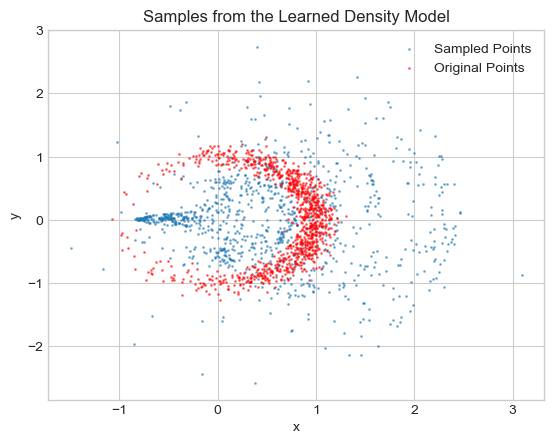

In [14]:
samples = flow.sample(1000)  # Generate samples from the learned density model

plt.scatter(samples[:, 0], samples[:, 1], s=1, alpha=0.5, label='Sampled Points')
plt.scatter(x[:, 0], x[:, 1], s=1, alpha=0.5, color='red', label='Original Points')
plt.title('Samples from the Learned Density Model')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()

([<matplotlib.axis.YTick at 0x14b5d6810>,
 [Text(0, 0.0, '0.0'),
  Text(0, 0.5, '0.5'),
  Text(0, 1.0, '1.0'),
  Text(0, 1.5, '1.5')])

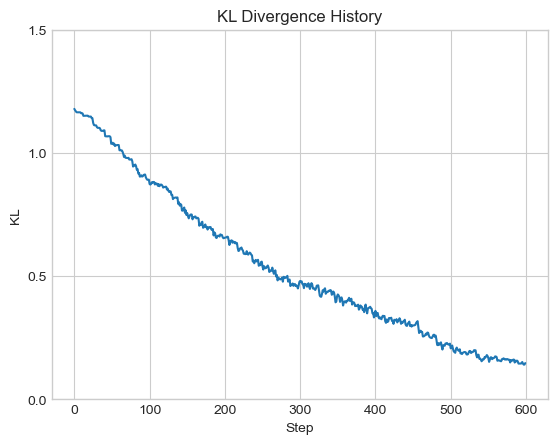

In [15]:
plt.plot(flow.kl_history)
plt.title('KL Divergence History')
plt.xlabel('Step')
plt.ylabel('KL')
plt.yticks([0, 0.5, 1.0, 1.5])

In [16]:
# Test Case 1
# This creates a crescent-shaped distribution, similar to the paper
m = 1000
angle = np.random.uniform(-np.pi/2, np.pi/2, m)
radius = 1.0 + 0.1 * np.random.randn(m)
x = np.zeros((m, 2))
x[:, 0] = radius * np.cos(angle)
x[:, 1] = radius * np.sin(angle)
x += 0.02 * np.random.randn(m, 2)

# Train the model
# Using parameters similar to the paper.
# n_p = 50
# n_steps = 500.
model = NormalizingFlow(n_p=50, epsilon=0.5)
model.fit(x, n_steps=600)

Step 60/600 completed
Step 120/600 completed
Step 180/600 completed
Step 240/600 completed
Step 300/600 completed
Step 360/600 completed
Step 420/600 completed
Step 480/600 completed
Step 540/600 completed
Step 600/600 completed


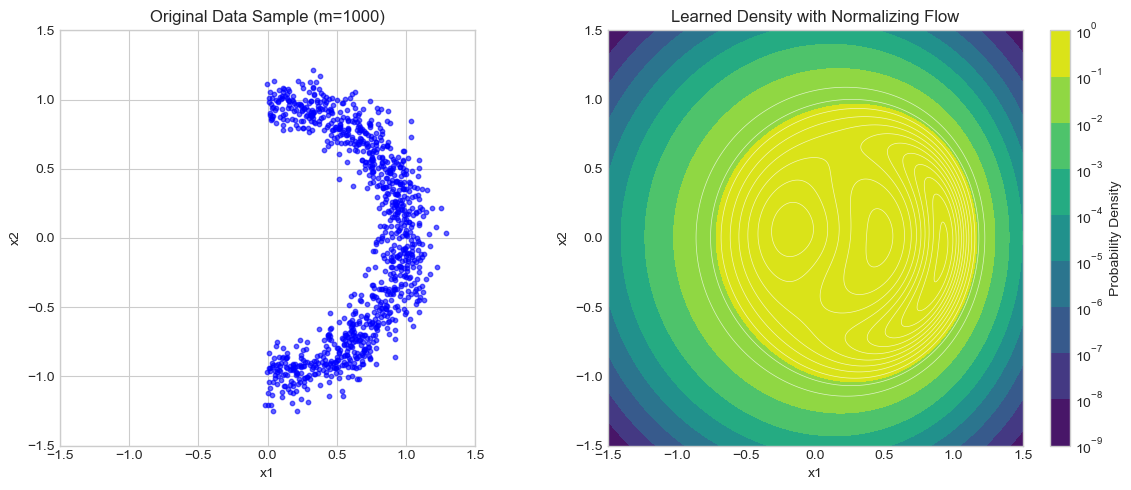

In [7]:
# Results
# Create a grid of points to evaluate the learned density
grid_res = 1000
x_range = np.linspace(-1.5, 1.5, grid_res)
y_range = np.linspace(-1.5, 1.5, grid_res)
xx, yy = np.meshgrid(x_range, y_range)
grid_points = np.c_[xx.ravel(), yy.ravel()]

# Calculate the probability on the grid
log_p = flow.log_prob(grid_points)
p = np.exp(log_p).reshape(grid_res, grid_res)

# Plotting
plt.style.use('seaborn-v0_8-whitegrid')
fig = plt.figure(figsize=(12, 5))

# Plot 1: Original Data
ax1 = fig.add_subplot(1, 2, 1)
ax1.scatter(x[:, 0], x[:, 1], s=10, alpha=0.6, c='blue')
ax1.set_title("Original Data Sample (m=1000)")
ax1.set_xlabel("x1")
ax1.set_ylabel("x2")
ax1.set_aspect('equal', adjustable='box')
ax1.set_xlim(-1.5, 1.5)
ax1.set_ylim(-1.5, 1.5)

# Plot 2: Learned Density
ax2 = fig.add_subplot(1, 2, 2)
# Use LogNorm for better visualization of low-density areas
contour = ax2.contourf(xx, yy, p, levels=15, cmap='viridis', norm=LogNorm())
ax2.contour(xx, yy, p, levels=15, colors='white', linewidths=0.5, alpha=0.7)
fig.colorbar(contour, ax=ax2, label="Probability Density")
ax2.set_title("Learned Density with Normalizing Flow")
ax2.set_xlabel("x1")
ax2.set_ylabel("x2")
ax2.set_aspect('equal', adjustable='box')
ax2.set_xlim(-1.5, 1.5)
ax2.set_ylim(-1.5, 1.5)

plt.tight_layout()
plt.show()

In [ ]:
def f_erf(r, alpha):
    """
    (Used above)
    
    f(r) = erf(r/α) / r
    """
    # Create an output array of the same shape and type as r
    f_vals = np.zeros_like(r, dtype=float)
    
    # Identify non-zero elements to avoid division by zero
    nonzero_r = r != 0
    
    # Calculate for non-zero r
    r_nz = r[nonzero_r]
    r_scaled = r_nz / alpha
    f_vals[nonzero_r] = erf(r_scaled) / r_nz
    
    # For r=0, use the limit: lim_{x->0} erf(x)/x = 2/sqrt(pi)
    f_vals[~nonzero_r] = 2.0 / (alpha * np.sqrt(np.pi))
    
    return f_vals

def F_erf_related(r, alpha):
    """
    Implements the function F(r) from the image.

    F(r) = r * erf(r/α) + (α/√π) * exp(-(r/α)²)
    """
    r_scaled = r / alpha
    term1 = r * erf(r_scaled)
    term2 = (alpha / np.sqrt(np.pi)) * np.exp(-r_scaled**2)
    return term1 + term2